# Chapter 3: Events Are Not Explanations

*Systems Thinking with AI* by Jason Karpeles

A reference mode is a behavior target, and the shapes it names depend on a few parameters.

**Goal.** Four small experiments with the chapter's reference-mode generators. Compare growth with S-shaped growth, goal seeking with decay, watch one erosion rate turn a ceiling into a collapse, and add measurement noise until a slow approach to a goal can no longer be told from scatter.

**Demonstrations**

1. Growth looks like S-shaped growth until the ceiling bites
2. Decay is goal seeking with the goal at zero
3. One erosion rate turns a ceiling into a collapse
4. Noise hides a slow approach first

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/03-reference-modes/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/03-reference-modes/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_03_reference_modes/code/validate_number.py`

In [2]:
%%module chapters.chapter_03_reference_modes.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_03_reference_modes/code/modes.py`

In [3]:
%%module chapters.chapter_03_reference_modes.code.modes
"""The six reference modes this book uses as behavior targets.

Each generator returns the full path of one variable over `steps` time steps of
length `dt`. A path is a behavior target, not a causal explanation: two different
structures can produce the same curve.
"""

import math

from .validate_number import validate_number


def _check(steps: int, dt: float) -> None:
    if type(steps) is not int or steps < 1:
        raise ValueError("steps must be a positive integer")
    validate_number(dt, "dt")
    if dt <= 0:
        raise ValueError("dt must be positive")


def exponential_growth(initial: float, rate: float, steps: int, dt: float = 1.0) -> list[float]:
    """Reinforcing growth: the net flow is proportional to the stock itself."""
    validate_number(initial, "initial")
    validate_number(rate, "rate")
    _check(steps, dt)
    path = [float(initial)]
    for _ in range(steps):
        path.append(path[-1] + dt * rate * path[-1])
    return path


def exponential_decay(initial: float, rate: float, steps: int, dt: float = 1.0) -> list[float]:
    """Balancing decay toward zero at a rate proportional to what remains."""
    validate_number(initial, "initial")
    validate_number(rate, "rate")
    _check(steps, dt)
    if rate < 0:
        raise ValueError("rate must be non-negative")
    path = [float(initial)]
    for _ in range(steps):
        path.append(path[-1] - dt * rate * path[-1])
    return path


def goal_seeking(
    initial: float, goal: float, adjustment_time: float, steps: int, dt: float = 1.0
) -> list[float]:
    """Balancing approach to a goal, closing a fixed fraction of the gap each step."""
    validate_number(initial, "initial")
    validate_number(goal, "goal")
    validate_number(adjustment_time, "adjustment_time")
    _check(steps, dt)
    if adjustment_time <= 0:
        raise ValueError("adjustment_time must be positive")
    path = [float(initial)]
    for _ in range(steps):
        path.append(path[-1] + dt * (goal - path[-1]) / adjustment_time)
    return path


def oscillation(
    level: float, amplitude: float, period: float, steps: int, dt: float = 1.0
) -> list[float]:
    """Repeated overshoot and undershoot around a level, with a fixed period."""
    validate_number(level, "level")
    validate_number(amplitude, "amplitude")
    validate_number(period, "period")
    _check(steps, dt)
    if period <= 0:
        raise ValueError("period must be positive")
    return [level + amplitude * math.sin(2 * math.pi * (i * dt) / period) for i in range(steps + 1)]


def s_shaped_growth(
    initial: float, capacity: float, rate: float, steps: int, dt: float = 1.0
) -> list[float]:
    """Reinforcing growth that a fixed carrying capacity progressively limits."""
    validate_number(initial, "initial")
    validate_number(capacity, "capacity")
    validate_number(rate, "rate")
    _check(steps, dt)
    if capacity <= 0:
        raise ValueError("capacity must be positive")
    path = [float(initial)]
    for _ in range(steps):
        current = path[-1]
        path.append(current + dt * rate * current * (1.0 - current / capacity))
    return path


def overshoot_and_collapse(
    initial: float,
    capacity: float,
    rate: float,
    erosion_rate: float,
    steps: int,
    dt: float = 1.0,
) -> list[float]:
    """S-shaped growth against a capacity that the stock itself erodes."""
    validate_number(initial, "initial")
    validate_number(capacity, "capacity")
    validate_number(rate, "rate")
    validate_number(erosion_rate, "erosion_rate")
    _check(steps, dt)
    if capacity <= 0:
        raise ValueError("capacity must be positive")
    if erosion_rate < 0:
        raise ValueError("erosion_rate must be non-negative")
    path = [float(initial)]
    remaining = float(capacity)
    for _ in range(steps):
        current = path[-1]
        limit = remaining if remaining > 0 else 0.0
        growth = rate * current * (1.0 - current / limit) if limit > 0 else -rate * current
        remaining = max(0.0, remaining - dt * erosion_rate * current)
        path.append(max(0.0, current + dt * growth))
    return path


`chapters/chapter_03_reference_modes/code/observe.py`

In [4]:
%%module chapters.chapter_03_reference_modes.code.observe
"""Add measurement noise to a clean path, with a seed so the run is reproducible."""

import random

from .validate_number import validate_number


def add_observation_noise(path: list[float], sd: float, seed: int) -> list[float]:
    """Return `path` with independent Gaussian measurement error, reproducible from `seed`."""
    validate_number(sd, "sd")
    if sd < 0:
        raise ValueError("sd must be non-negative")
    if type(seed) is not int:
        raise ValueError("seed must be an integer")
    if not path:
        raise ValueError("path must not be empty")
    rng = random.Random(seed)
    return [value + rng.gauss(0.0, sd) for value in path]


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [5]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [6]:
"""Chapter 3 reader: reference modes as shapes that parameters can move.

Every path comes from the Chapter 3 pack (exponential_growth, exponential_decay, goal_seeking,
s_shaped_growth, overshoot_and_collapse, add_observation_noise) so the reader, the pack and the
book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_03_reference_modes.code.modes import (
    exponential_decay,
    exponential_growth,
    goal_seeking,
    overshoot_and_collapse,
    s_shaped_growth,
)
from chapters.chapter_03_reference_modes.code.observe import add_observation_noise

EQ_S_SHAPED = "s_shaped_growth(initial=1.0, capacity=100.0, rate=0.3, steps=120)[-1]"
EQ_GOAL = "goal_seeking(initial=0.0, goal=100.0, adjustment_time=4.0, steps=60)"
EQ_NOISE = "add_observation_noise(clean_path, sd=1.0, seed=7)"
EQ_OVERSHOOT = "initial=1.0, capacity=100.0, rate=0.4, erosion_rate=0.02, steps=200"


# Demonstration 1: growth and S-shaped growth agree while the stock is far below the ceiling.

def growth_or_s_shape(steps_shown=20, capacity=100.0):
    n = int(steps_shown)
    growth = exponential_growth(initial=1.0, rate=0.3, steps=n)
    s_shape = s_shaped_growth(initial=1.0, capacity=capacity, rate=0.3, steps=n)
    xs = np.arange(0, n + 1)

    fig, ax = new_figure()
    ax.axhline(capacity, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(xs, growth, color=PALETTE["terracotta"], linewidth=2)
    ax.plot(xs, s_shape, color=PALETTE["navy"], linewidth=2)
    top = max(growth[-1], capacity) * 1.15
    ax.set_xlim(0, n * 1.25)
    ax.set_ylim(0, top)
    label_point(ax, n * 0.02, capacity, "Ceiling", color=PALETTE["grey"], dx=4, dy=6)
    label_point(ax, n, growth[-1], "Growth", color=PALETTE["terracotta"], dx=6, dy=10, ha="left", va="bottom")
    if growth[-1] > 2.5 * s_shape[-1]:
        label_point(ax, n, s_shape[-1], "S-shaped", color=PALETTE["navy"], dx=6, dy=10, ha="left", va="bottom")
    else:
        label_point(ax, n, s_shape[-1], "S-shaped", color=PALETTE["navy"], dx=6, dy=-10, ha="left", va="top")
    ax.set_xlabel("Step")
    ax.set_ylabel("Level of the stock")

    share = s_shape[-1] / capacity
    growth_share = growth[-1] / capacity
    first_g = 1.0 + 0.3 * 1.0
    first_s = 1.0 + 0.3 * 1.0 * (1.0 - 1.0 / capacity)
    metrics = {
        "Steps shown": n,
        "Growth level": fmt(growth[-1], 1),
        "S-shaped level": fmt(s_shape[-1], 1),
        "S-shaped level as a fraction of the ceiling": fmt(share, 2),
        "Growth level as a fraction of the ceiling": fmt(growth_share, 2),
    }
    if growth_share < 0.2:
        verdict = ("Both paths are still far below the ceiling, so the trace alone cannot say which "
                   "shape this is.")
    elif growth[-1] > capacity:
        verdict = "Growth has passed the ceiling that the S-shaped path is bending away from."
    else:
        verdict = "The paths have started to part, because the ceiling now bites."
    interpretation = (
        f"Step 1 is almost the same: growth 1 + 0.3 x 1 = {fmt(first_g, 3)}, S-shaped "
        f"1 + 0.3 x 1 x (1 - 1/{fmt(capacity, 0)}) = {fmt(first_s, 3)}. After {n} steps growth is "
        f"1 x 1.3^{n} = {fmt(growth[-1], 1)} and the S-shaped path is {fmt(s_shape[-1], 1)}, which is "
        f"{fmt(s_shape[-1], 1)} / {fmt(capacity, 0)} = {fmt(share, 2)} of the ceiling. {verdict}"
    )
    return fig, metrics, interpretation


# Demonstration 2: decay is goal seeking with the goal at zero.

def goal_or_decay(goal=0.0, adjustment_time=4.0):
    steps = 30
    start = 100.0
    seek = goal_seeking(initial=start, goal=goal, adjustment_time=adjustment_time, steps=steps)
    decay = exponential_decay(initial=start, rate=1.0 / adjustment_time, steps=steps)
    xs = np.arange(0, steps + 1)
    same = max(abs(a - b) for a, b in zip(seek, decay)) < 1e-9

    fig, ax = new_figure()
    ax.axhline(goal, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(xs, decay, color=PALETTE["terracotta"], linewidth=2.2 if same else 2, linestyle="solid")
    ax.plot(xs, seek, color=PALETTE["navy"], linewidth=2, linestyle="dotted" if same else "solid")
    ax.set_xlim(0, steps)
    ax.set_ylim(-8, 110)
    label_point(ax, steps, goal, f"Goal {fmt(goal, 0)}", color=PALETTE["grey"], dx=-6, dy=8, ha="right")
    k = int(steps * 0.4)
    if same:
        label_point(ax, k, decay[k], "Decay and goal seeking: one curve", color=PALETTE["navy"], dx=10, dy=22)
    else:
        label_point(ax, k, decay[k], "Decay", color=PALETTE["terracotta"], dx=10, dy=-14, va="top")
        label_point(ax, k, seek[k], "Goal seeking", color=PALETTE["navy"], dx=10, dy=12)
    ax.set_xlabel("Step")
    ax.set_ylabel("Level of the stock")

    first_seek = start + (goal - start) / adjustment_time
    first_decay = start - (1.0 / adjustment_time) * start
    ratio = 1.0 - 1.0 / adjustment_time
    at30 = goal + (start - goal) * ratio ** steps
    metrics = {
        "Goal": fmt(goal, 0),
        "Adjustment time (steps)": fmt(adjustment_time, 0),
        "Goal seeking after step 1": (fmt(first_seek, 2) if abs(round(first_seek * 100) % 10 - 5) == 0 and abs(first_seek * 100 - round(first_seek * 100)) < 1e-9 else fmt(first_seek, 1)),
        "Decay after step 1": fmt(first_decay, 1),
        f"Goal seeking after step {steps}": fmt(seek[-1], 2),
        f"Decay after step {steps}": fmt(decay[-1], 2),
        "Same curve": "yes, an exact tie" if same else "no",
    }
    if same:
        verdict = ("The two curves tie exactly, because decay is goal seeking whose goal is zero. "
                   "The label decay quietly claims that the target is zero.")
    else:
        verdict = (f"The curves part: decay keeps heading for 0 while goal seeking levels off at "
                   f"{fmt(goal, 0)}. Same shape, different mechanism, so the goal is the thing to find out.")
    interpretation = (
        f"Goal seeking, step 1: {fmt(start, 0)} + ({fmt(goal, 0)} - {fmt(start, 0)}) / {fmt(adjustment_time, 0)} = "
        f"{fmt(first_seek, 1)}. Decay, step 1: {fmt(start, 0)} - {fmt(1 / adjustment_time, 2)} x {fmt(start, 0)} = "
        f"{fmt(first_decay, 1)}. After {steps} steps goal seeking is {fmt(goal, 0)} + "
        f"({fmt(start, 0)} - {fmt(goal, 0)}) x {fmt(ratio, 2)}^{steps} = {fmt(at30, 2)}. {verdict}"
    )
    return fig, metrics, interpretation


# Demonstration 3: the erosion rate is the single difference between S-shaped growth and collapse.

def erosion(erosion_rate=0.02, rate=0.4):
    steps = 200
    path = overshoot_and_collapse(initial=1.0, capacity=100.0, rate=rate, erosion_rate=erosion_rate, steps=steps)
    xs = np.arange(0, steps + 1)
    peak = max(path)
    peak_step = path.index(peak)
    final = path[-1]
    turns = erosion_rate > 0 and final < peak - 1e-6

    fig, ax = new_figure()
    ax.axhline(100, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(xs, path, color=PALETTE["navy"], linewidth=2)
    ax.set_xlim(0, steps)
    ax.set_ylim(0, 118)
    label_point(ax, steps, 100, "Original ceiling 100", color=PALETTE["grey"], dx=-6, dy=6, ha="right")
    if turns:
        label_point(ax, peak_step, peak, f"Peak {fmt(peak, 1)}", color=PALETTE["terracotta"], dx=14, dy=-4, va="top")
        ax.plot([peak_step], [peak], marker="o", color=PALETTE["terracotta"])
    ax.set_xlabel("Step")
    ax.set_ylabel("Level of the stock")

    first = 1.0 + rate * 1.0 * (1.0 - 1.0 / 100.0)
    ceiling_after = 100.0 - erosion_rate * 1.0
    metrics = {
        "Erosion rate": fmt(erosion_rate, 2),
        "Growth rate": fmt(rate, 1),
        "Highest level": fmt(peak, 1),
        "Turning point (step)": str(peak_step) if turns else "none, the path never turns down",
        f"Level at step {steps}": fmt(final, 2),
    }
    if turns:
        verdict = (f"The path peaks at {fmt(peak, 1)}, {fmt(100 - peak, 1)} below the original ceiling, and "
                   f"ends at {fmt(final, 2)}: overshoot and collapse.")
    else:
        verdict = (f"With erosion at zero the ceiling never moves, so the path settles at {fmt(final, 1)}: "
                   f"S-shaped growth, and the second curve has become the first.")
    interpretation = (
        f"Step 1: 1 + {fmt(rate, 1)} x 1 x (1 - 1/100) = {fmt(first, 3)}, and the ceiling falls to "
        f"100 - {fmt(erosion_rate, 2)} x 1 = {fmt(ceiling_after, 2)}. That small cut repeats every step, in "
        f"proportion to the stock. {verdict}"
    )
    return fig, metrics, interpretation


# Demonstration 4: observation noise hides the shape, and a slow approach hides first.

def noisy_goal(adjustment_time=4.0, sd=5.0):
    steps = 60
    clean = goal_seeking(initial=0.0, goal=100.0, adjustment_time=adjustment_time, steps=steps)
    noisy = add_observation_noise(clean, sd=sd, seed=7)
    xs = np.arange(0, steps + 1)
    increments = [clean[i] - clean[i - 1] for i in range(1, steps + 1)]
    visible = sum(1 for d in increments if d > sd)

    fig, ax = new_figure()
    ax.plot(xs, noisy, marker="o", markersize=3.5, linestyle="none", color=PALETTE["terracotta"])
    ax.plot(xs, clean, color=PALETTE["navy"], linewidth=2)
    ax.set_xlim(0, steps)
    ax.set_ylim(-75, 175)
    label_point(ax, steps, clean[-1], "Clean path", color=PALETTE["navy"], dx=-6, dy=-8, ha="right", va="top")
    label_point(ax, 2, -45, f"Observed, sd {fmt(sd, 0)}", color=PALETTE["terracotta"], dx=0, dy=0)
    ax.set_xlabel("Step")
    ax.set_ylabel("Observed level")

    step10 = (100.0 - clean[9]) / adjustment_time
    metrics = {
        "Adjustment time (steps)": fmt(adjustment_time, 0),
        "Noise standard deviation": fmt(sd, 0),
        "Move at step 1 (clean)": fmt(increments[0], 2),
        "Move at step 10 (clean)": fmt(increments[9], 2),
        "Steps whose clean move exceeds the noise sd": f"{visible} of {steps}",
    }
    interpretation = (
        f"The clean move at step 1 is (100 - 0) / {fmt(adjustment_time, 0)} = {fmt(increments[0], 2)}. At step 10 "
        f"it is (100 - {fmt(clean[9], 2)}) / {fmt(adjustment_time, 0)} = {fmt(step10, 2)}. Against a noise "
        f"standard deviation of {fmt(sd, 0)}, {visible} of the {steps} steps move the clean path by more than "
        f"that. The seed is fixed at 7, so only the noise level and the adjustment time change the picture. "
        f"Whether the shape survives is a property of the record, and a slower approach is the first to vanish as the noise grows, because its largest move is only 100 / adjustment_time."
    )
    return fig, metrics, interpretation


## 1. Growth looks like S-shaped growth until the ceiling bites

*While a stock is far below its ceiling, can the trace tell growth from S-shaped growth?*

S-shaped growth multiplies the growth term by (1 - level / capacity). While the level is tiny against the capacity that factor is close to 1, so the two paths agree. As the level nears the ceiling the factor shrinks and the S-shaped path flattens.

    s_shaped_growth(initial=1.0, capacity=100.0, rate=0.3, steps=120)[-1]

**Symbols and inputs.** Both paths start at 1 and use a rate of 0.3 per step. The S-shaped path also takes a capacity, the ceiling, in the same units as the stock. The level is a count of anything that accumulates.

**Predict first.** After 10 steps with a ceiling of 100, are the growth and S-shaped levels close or far apart?

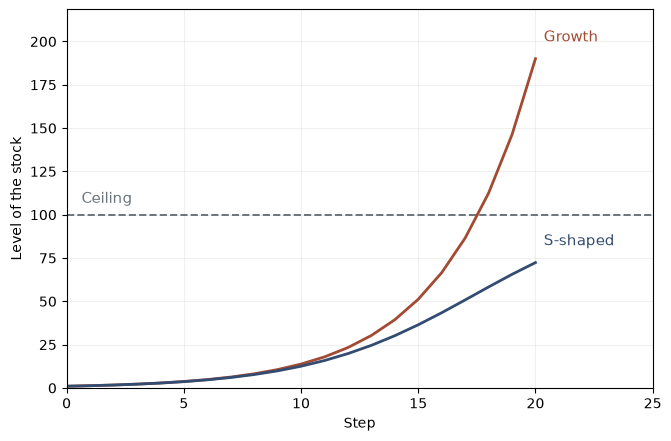

- **Steps shown:** 20
- **Growth level:** 190.0
- **S-shaped level:** 72.4
- **S-shaped level as a fraction of the ceiling:** 0.72
- **Growth level as a fraction of the ceiling:** 1.90

Step 1 is almost the same: growth 1 + 0.3 x 1 = 1.300, S-shaped 1 + 0.3 x 1 x (1 - 1/100) = 1.297. After 20 steps growth is 1 x 1.3^20 = 190.0 and the S-shaped path is 72.4, which is 72.4 / 100 = 0.72 of the ceiling. Growth has passed the ceiling that the S-shaped path is bending away from.

In [7]:
show(growth_or_s_shape(steps_shown=20, capacity=100.0))

**Use the idea.** Before labeling a rising trace as growth, write down an estimate of the limit and where the current level sits against it, because the trace alone does not carry that.

**Where the conclusion applies.** A fixed ceiling, a start of 1 and a constant rate of 0.3. The comparison fails if the limit itself moves, which is the next demonstration's subject.

*Constructed example: the start, rate and ceiling of the chapter's neighbor-confusion figure, recomputed with the chapter's generators.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(growth_or_s_shape, [('steps_shown', [10, 15, 20, 25]), ('capacity', [100.0, 50.0])])

- **steps_shown = 10, capacity = 100.0**: Steps shown 10; Growth level 13.8; S-shaped level 12.5; S-shaped level as a fraction of the ceiling 0.13; Growth level as a fraction of the ceiling 0.14
- **steps_shown = 10, capacity = 50.0**: Steps shown 10; Growth level 13.8; S-shaped level 11.5; S-shaped level as a fraction of the ceiling 0.23; Growth level as a fraction of the ceiling 0.28
- **steps_shown = 15, capacity = 100.0**: Steps shown 15; Growth level 51.2; S-shaped level 36.5; S-shaped level as a fraction of the ceiling 0.36; Growth level as a fraction of the ceiling 0.51
- **steps_shown = 15, capacity = 50.0**: Steps shown 15; Growth level 51.2; S-shaped level 27.9; S-shaped level as a fraction of the ceiling 0.56; Growth level as a fraction of the ceiling 1.02
- **steps_shown = 20, capacity = 100.0**: Steps shown 20; Growth level 190.0; S-shaped level 72.4; S-shaped level as a fraction of the ceiling 0.72; Growth level as a fraction of the ceiling 1.90
- **steps_shown = 20, capacity = 50.0**: Steps shown 20; Growth level 190.0; S-shaped level 43.2; S-shaped level as a fraction of the ceiling 0.86; Growth level as a fraction of the ceiling 3.80
- **steps_shown = 25, capacity = 100.0**: Steps shown 25; Growth level 705.6; S-shaped level 93.3; S-shaped level as a fraction of the ceiling 0.93; Growth level as a fraction of the ceiling 7.06
- **steps_shown = 25, capacity = 50.0**: Steps shown 25; Growth level 705.6; S-shaped level 48.6; S-shaped level as a fraction of the ceiling 0.97; Growth level as a fraction of the ceiling 14.11

## 2. Decay is goal seeking with the goal at zero

*What separates a decay trace from a goal-seeking trace?*

Each step closes 1 / adjustment_time of the remaining gap. When the goal is zero the gap is the stock, so the update is the decay update. Any other goal changes where the path ends, not the way it approaches.

    goal_seeking(initial=0.0, goal=100.0, adjustment_time=4.0, steps=60)

**Symbols and inputs.** The stock starts at 100. The goal is the level the path closes toward. The adjustment time is how many steps it takes to close the whole gap at the first step's pace; the decay rate is 1 divided by that time.

**Predict first.** With a goal of 40, does the stock keep falling toward zero or level off near 40?

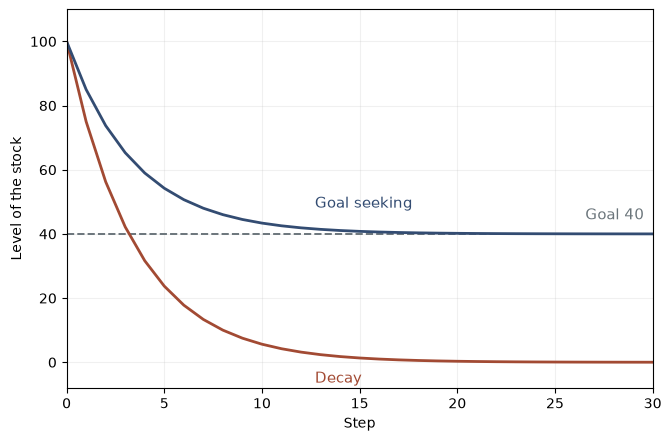

- **Goal:** 40
- **Adjustment time (steps):** 4
- **Goal seeking after step 1:** 85.0
- **Decay after step 1:** 75.0
- **Goal seeking after step 30:** 40.01
- **Decay after step 30:** 0.02
- **Same curve:** no

Goal seeking, step 1: 100 + (40 - 100) / 4 = 85.0. Decay, step 1: 100 - 0.25 x 100 = 75.0. After 30 steps goal seeking is 40 + (100 - 40) x 0.75^30 = 40.01. The curves part: decay keeps heading for 0 while goal seeking levels off at 40. Same shape, different mechanism, so the goal is the thing to find out.

In [9]:
show(goal_or_decay(goal=40.0, adjustment_time=4.0))

**Use the idea.** When a trace falls and flattens, ask what level it is flattening toward before calling it decay, since the label asserts a target of zero.

**Where the conclusion applies.** Discrete steps of length 1 and a goal that does not move. If the goal drifts, the trace shows a different shape.

*Constructed example: the goal-seeking call printed in the chapter, run downward from a start of 100 and compared with the chapter's decay generator.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(goal_or_decay, [('goal', [0.0, 40.0, 70.0]), ('adjustment_time', [4.0, 8.0])])

- **goal = 0.0, adjustment_time = 4.0**: Goal 0; Adjustment time (steps) 4; Goal seeking after step 1 75.0; Decay after step 1 75.0; Goal seeking after step 30 0.02; Decay after step 30 0.02; Same curve yes, an exact tie
- **goal = 0.0, adjustment_time = 8.0**: Goal 0; Adjustment time (steps) 8; Goal seeking after step 1 87.5; Decay after step 1 87.5; Goal seeking after step 30 1.82; Decay after step 30 1.82; Same curve yes, an exact tie
- **goal = 40.0, adjustment_time = 4.0**: Goal 40; Adjustment time (steps) 4; Goal seeking after step 1 85.0; Decay after step 1 75.0; Goal seeking after step 30 40.01; Decay after step 30 0.02; Same curve no
- **goal = 40.0, adjustment_time = 8.0**: Goal 40; Adjustment time (steps) 8; Goal seeking after step 1 92.5; Decay after step 1 87.5; Goal seeking after step 30 41.09; Decay after step 30 1.82; Same curve no
- **goal = 70.0, adjustment_time = 4.0**: Goal 70; Adjustment time (steps) 4; Goal seeking after step 1 92.5; Decay after step 1 75.0; Goal seeking after step 30 70.01; Decay after step 30 0.02; Same curve no
- **goal = 70.0, adjustment_time = 8.0**: Goal 70; Adjustment time (steps) 8; Goal seeking after step 1 96.25; Decay after step 1 87.5; Goal seeking after step 30 70.55; Decay after step 30 1.82; Same curve no

## 3. One erosion rate turns a ceiling into a collapse

*What does the stock do when it wears away the limit it is growing toward?*

The ceiling falls by erosion_rate x stock every step. Once the stock grows past the shrinking ceiling, its growth term turns negative and the stock falls. With zero erosion the ceiling never moves and the path is S-shaped.

    initial=1.0, capacity=100.0, rate=0.4, erosion_rate=0.02, steps=200

**Symbols and inputs.** The stock starts at 1 against a ceiling of 100. The rate is the growth per step. The erosion rate is how much of the ceiling each unit of stock removes per step.

**Predict first.** At erosion rate 0.02 and growth rate 0.4, does the path settle at 100 or turn over?

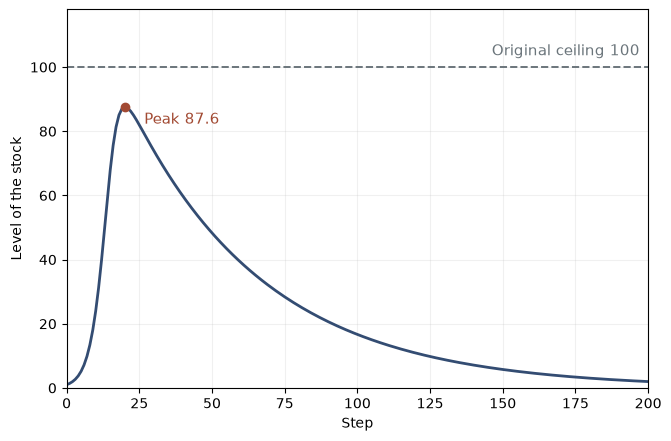

- **Erosion rate:** 0.02
- **Growth rate:** 0.4
- **Highest level:** 87.6
- **Turning point (step):** 20
- **Level at step 200:** 1.99

Step 1: 1 + 0.4 x 1 x (1 - 1/100) = 1.396, and the ceiling falls to 100 - 0.02 x 1 = 99.98. That small cut repeats every step, in proportion to the stock. The path peaks at 87.6, 12.4 below the original ceiling, and ends at 1.99: overshoot and collapse.

In [11]:
show(erosion(erosion_rate=0.02, rate=0.4))

**Use the idea.** A flattening trace is ambiguous at the moment it flattens. Ask whether the limit is fixed or whether the stock consumes it, which usually comes from knowing the system.

**Where the conclusion applies.** A linear erosion of the ceiling, 200 steps and no recovery of the ceiling. A system whose limit regrows would not collapse this way.

*Constructed example: the overshoot call printed in the chapter, varying its erosion and growth rates.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(erosion, [('erosion_rate', [0.0, 0.01, 0.02, 0.05]), ('rate', [0.2, 0.4])])

- **erosion_rate = 0.0, rate = 0.2**: Erosion rate 0.00; Growth rate 0.2; Highest level 100.0; Turning point (step) none, the path never turns down; Level at step 200 100.00
- **erosion_rate = 0.0, rate = 0.4**: Erosion rate 0.00; Growth rate 0.4; Highest level 100.0; Turning point (step) none, the path never turns down; Level at step 200 100.00
- **erosion_rate = 0.01, rate = 0.2**: Erosion rate 0.01; Growth rate 0.2; Highest level 86.5; Turning point (step) 39; Level at step 200 16.53
- **erosion_rate = 0.01, rate = 0.4**: Erosion rate 0.01; Growth rate 0.4; Highest level 92.3; Turning point (step) 22; Level at step 200 14.97
- **erosion_rate = 0.02, rate = 0.2**: Erosion rate 0.02; Growth rate 0.2; Highest level 78.9; Turning point (step) 36; Level at step 200 2.19
- **erosion_rate = 0.02, rate = 0.4**: Erosion rate 0.02; Growth rate 0.4; Highest level 87.6; Turning point (step) 20; Level at step 200 1.99
- **erosion_rate = 0.05, rate = 0.2**: Erosion rate 0.05; Growth rate 0.2; Highest level 65.0; Turning point (step) 32; Level at step 200 0.00
- **erosion_rate = 0.05, rate = 0.4**: Erosion rate 0.05; Growth rate 0.4; Highest level 77.6; Turning point (step) 18; Level at step 200 0.00

## 4. Noise hides a slow approach first

*How much measurement noise can a goal-seeking path take before its shape is lost?*

The clean path moves by (goal - level) / adjustment_time per step, a geometric sequence. A fast approach makes a few large moves early; a slow one never moves by more than its first step, goal / adjustment_time, so once the noise passes that size none of its moves stand out.

    add_observation_noise(clean_path, sd=1.0, seed=7)
    goal_seeking(initial=0.0, goal=100.0, adjustment_time=4.0, steps=60)

**Symbols and inputs.** The clean path closes toward a goal of 100 from 0. Each observation adds Gaussian error with standard deviation sd. The seed is fixed, so a run can be repeated exactly.

**Predict first.** At sd 20 and an adjustment time of 4, on how many of the 60 steps does the clean path move by more than the noise?

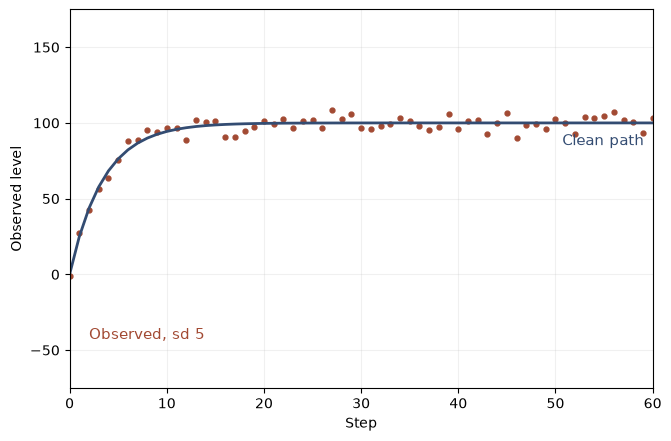

- **Adjustment time (steps):** 4
- **Noise standard deviation:** 5
- **Move at step 1 (clean):** 25.00
- **Move at step 10 (clean):** 1.88
- **Steps whose clean move exceeds the noise sd:** 6 of 60

The clean move at step 1 is (100 - 0) / 4 = 25.00. At step 10 it is (100 - 92.49) / 4 = 1.88. Against a noise standard deviation of 5, 6 of the 60 steps move the clean path by more than that. The seed is fixed at 7, so only the noise level and the adjustment time change the picture. Whether the shape survives is a property of the record, and a slower approach is the first to vanish as the noise grows, because its largest move is only 100 / adjustment_time.

In [13]:
show(noisy_goal(adjustment_time=4.0, sd=5.0))

**Use the idea.** Before claiming a pattern in a real series, ask what noise level the pattern would survive, and record the smoothing or exclusion choices in the treatment field.

**Where the conclusion applies.** Independent Gaussian error and one fixed seed. Real measurement error can be correlated or change over the window, which would make the picture look different.

*Constructed example: the chapter's noise experiment with seed 7, using the standard deviations 1, 5 and 20.*

Every setting the interactive reader offers for this demonstration:

In [14]:
sweep(noisy_goal, [('adjustment_time', [4.0, 12.0]), ('sd', [1.0, 5.0, 20.0])])

- **adjustment_time = 4.0, sd = 1.0**: Adjustment time (steps) 4; Noise standard deviation 1; Move at step 1 (clean) 25.00; Move at step 10 (clean) 1.88; Steps whose clean move exceeds the noise sd 12 of 60
- **adjustment_time = 4.0, sd = 5.0**: Adjustment time (steps) 4; Noise standard deviation 5; Move at step 1 (clean) 25.00; Move at step 10 (clean) 1.88; Steps whose clean move exceeds the noise sd 6 of 60
- **adjustment_time = 4.0, sd = 20.0**: Adjustment time (steps) 4; Noise standard deviation 20; Move at step 1 (clean) 25.00; Move at step 10 (clean) 1.88; Steps whose clean move exceeds the noise sd 1 of 60
- **adjustment_time = 12.0, sd = 1.0**: Adjustment time (steps) 12; Noise standard deviation 1; Move at step 1 (clean) 8.33; Move at step 10 (clean) 3.81; Steps whose clean move exceeds the noise sd 25 of 60
- **adjustment_time = 12.0, sd = 5.0**: Adjustment time (steps) 12; Noise standard deviation 5; Move at step 1 (clean) 8.33; Move at step 10 (clean) 3.81; Steps whose clean move exceeds the noise sd 6 of 60
- **adjustment_time = 12.0, sd = 20.0**: Adjustment time (steps) 12; Noise standard deviation 20; Move at step 1 (clean) 8.33; Move at step 10 (clean) 3.81; Steps whose clean move exceeds the noise sd 0 of 60

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With a ceiling of 50 and 15 steps shown, is the S-shaped level above or below half of the ceiling?

<details><summary>Answer</summary>

The S-shaped level is about 27.9 on a ceiling of 50, so 27.9 / 50 = 0.56, just above half.

</details>

### Exercise 2

With a goal of 70 and an adjustment time of 4, what is the level after the first step from 100?

<details><summary>Answer</summary>

100 + (70 - 100) / 4 = 92.5.

</details>

### Exercise 3

At erosion 0.02 and growth rate 0.4, by how much does the ceiling fall at the first step from a stock of 1?

<details><summary>Answer</summary>

0.02 x 1 = 0.02, so the ceiling goes from 100 to 99.98.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/